# **Student performance**

Academic performance is influenced by multiple factors, including attendance, study habits, previous academic records, participation in activities, and socio-economic background. The objective of this project is to analyze student-related data and develop a machine learning model that can predict whether a student will achieve satisfactory academic performance based on these influencing factors.

The dataset includes attributes such as attendance percentage, internal assessment marks, previous semester grade, daily study hours, participation in extracurricular activities, and socio-economic score. By examining these variables, the goal is to identify key contributors to student success or underperformance and build a reliable predictive model. This solution can assist educational institutions in identifying at-risk students early and implementing targeted academic support strategies to improve overall student outcomes.

## **load and inspect the data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/student_performance_dataset.csv")
df

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,1,64,54,D,8.6,1,5,0
1,2,85,90,B,7.1,1,2,1
2,3,63,97,D,8.4,1,5,1
3,4,79,43,E,7.2,1,4,0
4,5,83,96,B,4.2,1,4,1
...,...,...,...,...,...,...,...,...
99995,99996,69,78,C,9.5,0,4,1
99996,99997,96,76,B,2.8,1,4,1
99997,99998,76,65,C,9.3,1,5,1
99998,99999,88,72,B,2.8,1,5,1


In [ ]:
df.head()

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,1,64,54,D,8.6,1,5,0
1,2,85,90,B,7.1,1,2,1
2,3,63,97,D,8.4,1,5,1
3,4,79,43,E,7.2,1,4,0
4,5,83,96,B,4.2,1,4,1


In [ ]:
df.tail()

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
99995,99996,69,78,C,9.5,0,4,1
99996,99997,96,76,B,2.8,1,4,1
99997,99998,76,65,C,9.3,1,5,1
99998,99999,88,72,B,2.8,1,5,1
99999,100000,75,78,C,6.8,0,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  int64  
 1   Attendance_Percentage        100000 non-null  int64  
 2   Internal_Assessment_Marks    100000 non-null  int64  
 3   Previous_Semester_Grade      100000 non-null  object 
 4   Study_Hours_Per_Day          100000 non-null  float64
 5   Participation_in_Activities  100000 non-null  int64  
 6   Socio_Economic_Score         100000 non-null  int64  
 7   Performance                  100000 non-null  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 6.1+ MB


## **cleaning**

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Participation_in_Activities,0
Socio_Economic_Score,0
Performance,0


In [ ]:
df.shape

(100000, 8)

In [ ]:
df.duplicated().sum()

np.int64(0)

## **visualization**

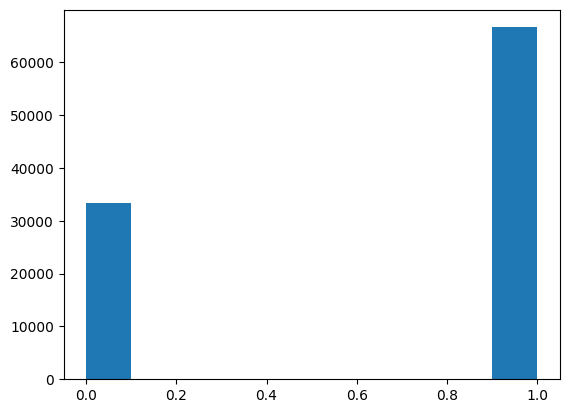

In [ ]:
plt.hist(df["Performance"])
plt.show()

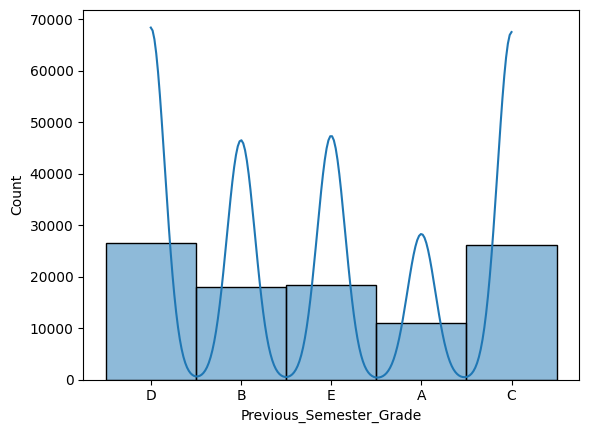

In [ ]:
sns.histplot(df["Previous_Semester_Grade"], kde=True)
plt.show()

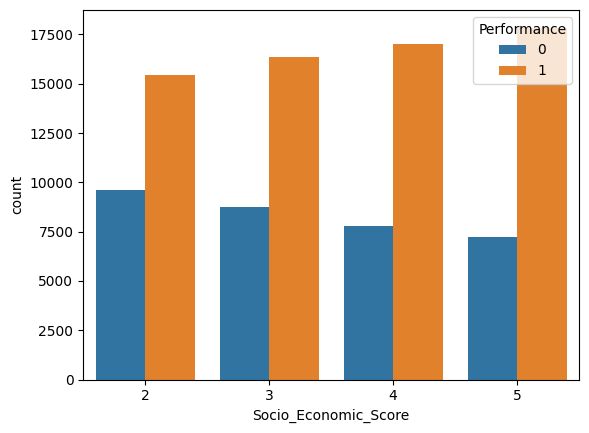

In [ ]:
sns.countplot(data=df, x="Socio_Economic_Score", hue="Performance")
plt.show()

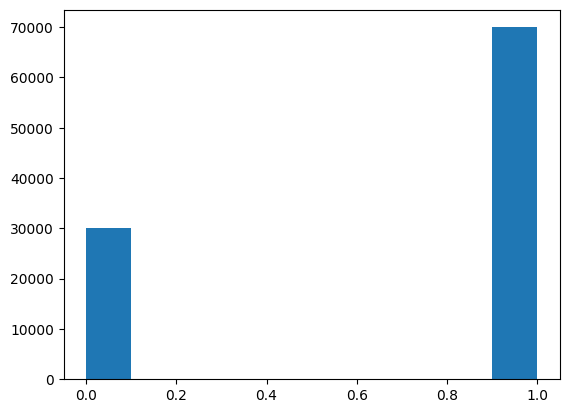

In [ ]:
plt.hist(df["Participation_in_Activities"])
plt.show()

<Axes: xlabel='Study_Hours_Per_Day', ylabel='Previous_Semester_Grade'>

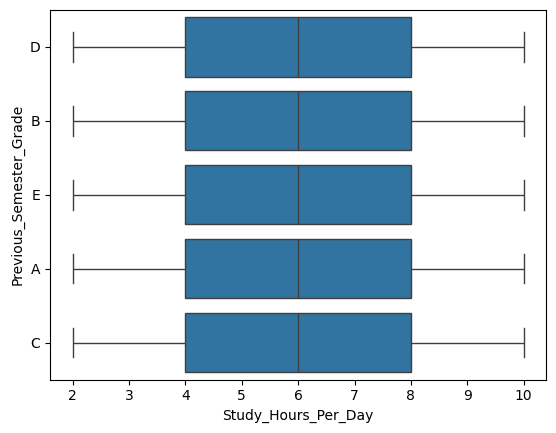

In [ ]:
sns.boxplot(x="Study_Hours_Per_Day", y="Previous_Semester_Grade", data=df)

## **correlation**

In [ ]:
df.head()

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,1,64,54,D,8.6,1,5,0
1,2,85,90,B,7.1,1,2,1
2,3,63,97,D,8.4,1,5,1
3,4,79,43,E,7.2,1,4,0
4,5,83,96,B,4.2,1,4,1


In [ ]:
print(df["Previous_Semester_Grade"].unique())

['D' 'B' 'E' 'A' 'C']


In [ ]:
df["Previous_Semester_Grade"].replace(['A', 'B', 'C', 'D', 'E'], [1, 2, 3, 4, 5], inplace=True)

/tmp/ipython-input-206/3109868131.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Previous_Semester_Grade"].replace(['A', 'B', 'C', 'D', 'E'], [1, 2, 3, 4, 5], inplace=True)
/tmp/ipython-input-206/3109868131.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Previous_Semester_Grade"].re

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  int64  
 1   Attendance_Percentage        100000 non-null  int64  
 2   Internal_Assessment_Marks    100000 non-null  int64  
 3   Previous_Semester_Grade      100000 non-null  int64  
 4   Study_Hours_Per_Day          100000 non-null  float64
 5   Participation_in_Activities  100000 non-null  int64  
 6   Socio_Economic_Score         100000 non-null  int64  
 7   Performance                  100000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 6.1 MB


In [ ]:
df

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,1,64,54,4,8.6,1,5,0
1,2,85,90,2,7.1,1,2,1
2,3,63,97,4,8.4,1,5,1
3,4,79,43,5,7.2,1,4,0
4,5,83,96,2,4.2,1,4,1
...,...,...,...,...,...,...,...,...
99995,99996,69,78,3,9.5,0,4,1
99996,99997,96,76,2,2.8,1,4,1
99997,99998,76,65,3,9.3,1,5,1
99998,99999,88,72,2,2.8,1,5,1


### **oversampling-SMOTE**

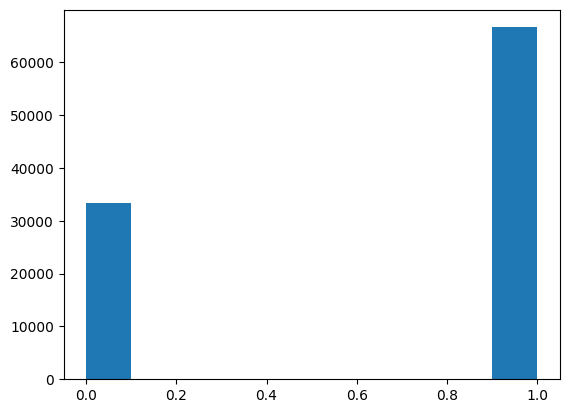

In [ ]:
plt.hist(df["Performance"])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

x = df.drop("Performance", axis=1)
y = df["Performance"]

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [ ]:
df_balanced = pd.concat([pd.DataFrame(x_resampled, columns=x.columns), pd.Series(y_resampled, name="Performance")], axis=1)

df_balanced.head()

,Student_ID,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,1,64,54,4,8.6,1,5,0
1,2,85,90,2,7.1,1,2,1
2,3,63,97,4,8.4,1,5,1
3,4,79,43,5,7.2,1,4,0
4,5,83,96,2,4.2,1,4,1


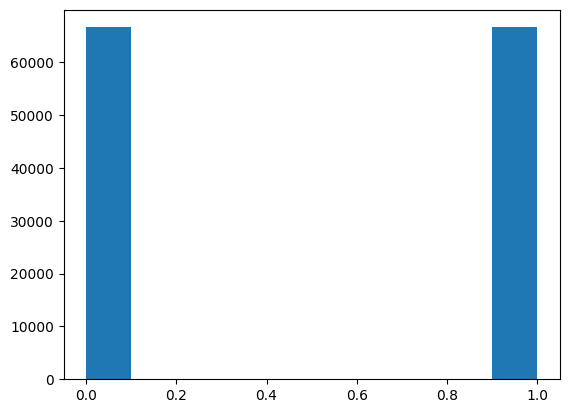

In [ ]:
plt.hist(df_balanced["Performance"])
plt.show()

In [ ]:
df = df_balanced

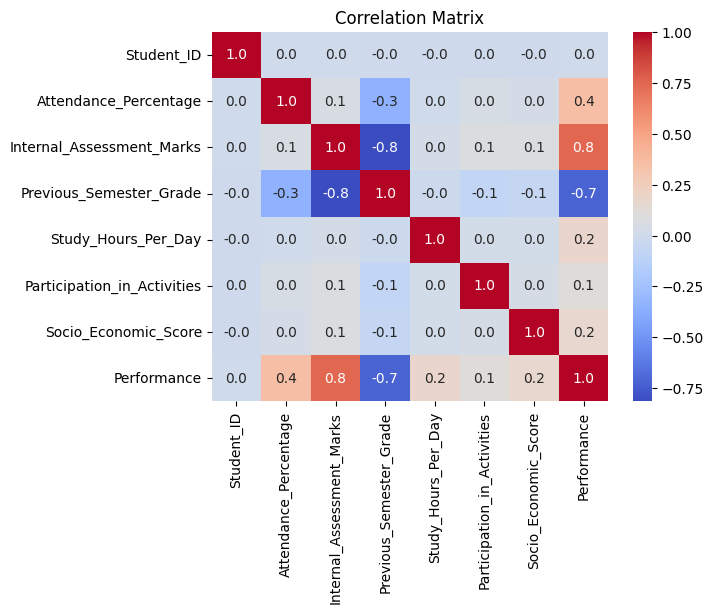

In [ ]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop(["Previous_Semester_Grade"], inplace=True, axis=1)

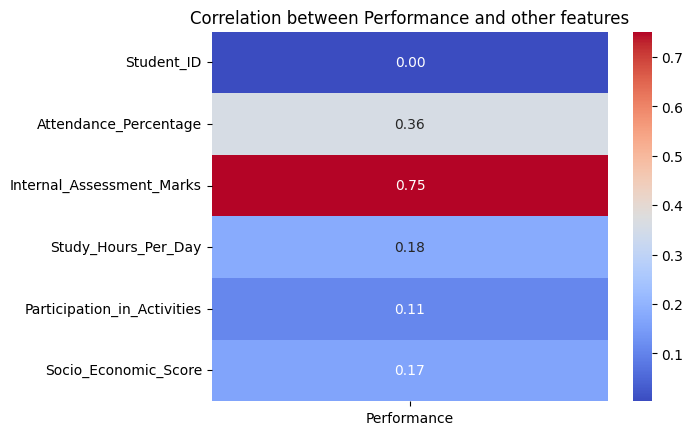

In [ ]:
Performance_corr = df.corr()["Performance"]
Performance_corr = Performance_corr.drop("Performance")

sns.heatmap(Performance_corr.to_frame(), annot=True, fmt='0.2f', cmap='coolwarm', cbar=True, annot_kws={'size':10})

plt.title("Correlation between Performance and other features")
plt.show()

In [ ]:
df.drop(["Student_ID"], axis=1, inplace=True)

In [ ]:
df

,Attendance_Percentage,Internal_Assessment_Marks,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,64,54,8.600000,1,5,0
1,85,90,7.100000,1,2,1
2,63,97,8.400000,1,5,1
3,79,43,7.200000,1,4,0
4,83,96,4.200000,1,4,1
...,...,...,...,...,...,...
133289,83,52,5.957856,0,2,0
133290,80,46,8.594248,0,4,0
133291,67,45,6.100820,1,3,0
133292,97,42,3.916308,1,4,0


## **outlier checking and removing**

<Axes: >

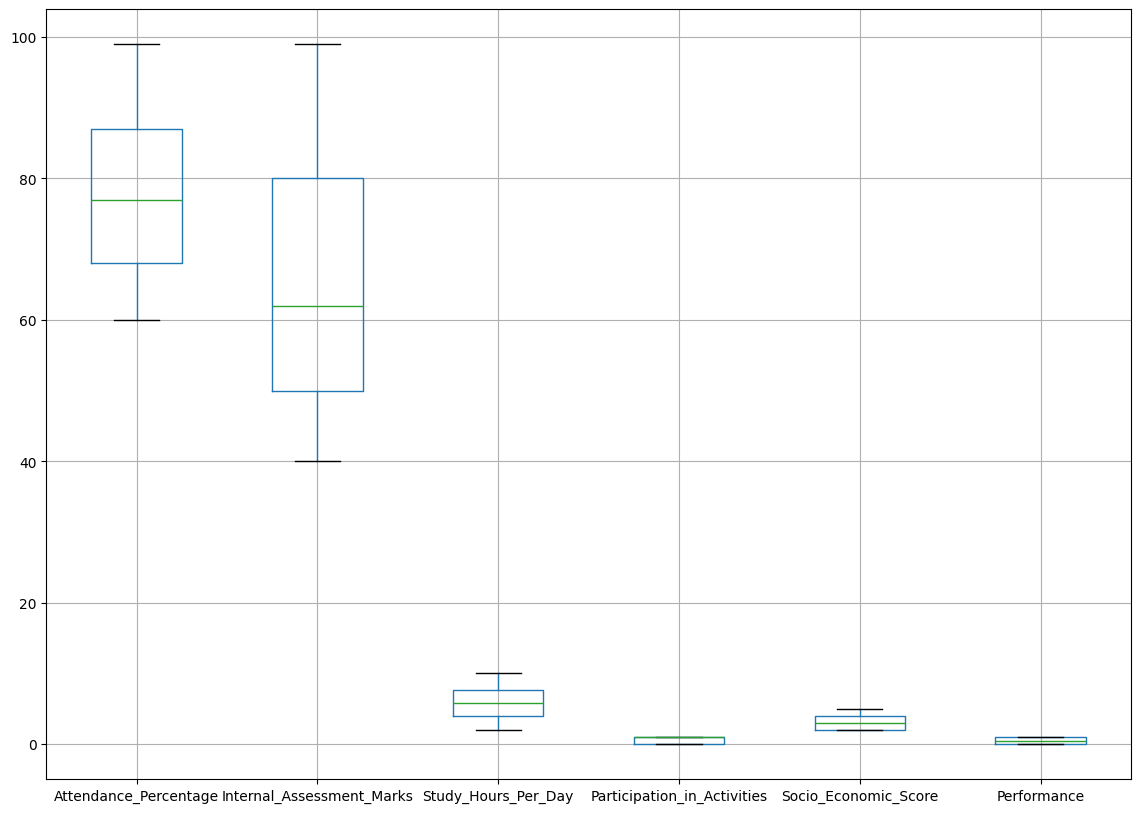

In [ ]:
plt.figure(figsize= (14,10))

df.boxplot()

## **train test split**

In [ ]:
df

,Attendance_Percentage,Internal_Assessment_Marks,Study_Hours_Per_Day,Participation_in_Activities,Socio_Economic_Score,Performance
0,64,54,8.600000,1,5,0
1,85,90,7.100000,1,2,1
2,63,97,8.400000,1,5,1
3,79,43,7.200000,1,4,0
4,83,96,4.200000,1,4,1
...,...,...,...,...,...,...
133289,83,52,5.957856,0,2,0
133290,80,46,8.594248,0,4,0
133291,67,45,6.100820,1,3,0
133292,97,42,3.916308,1,4,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x = df[['Attendance_Percentage', 'Internal_Assessment_Marks', 'Study_Hours_Per_Day', 'Participation_in_Activities', 'Socio_Economic_Score']]
y = df['Performance']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f'Baseline model accuracy: {accuracy: 0.2f}')

Baseline model accuracy:  0.97


In [ ]:
model.predict([[85,90,7.1,1,2]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

## **kfold**

In [ ]:
from sklearn.model_selection import KFold

x = df.drop("Performance", axis=1)
y = df["Performance"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()

best_accuracy = 0
best_fold = -1

best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  model.fit(x_train,y_train)

  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"Fold {fold} Accuracy: {acc}")

  if acc > best_accuracy:
     best_accuracy = acc
     best_fold = fold
     best_x_train = x_train
     best_y_train = y_train
     best_x_test = x_test
     best_y_test = y_test
     best_y_pred = y_pred


print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.9725421058554334
Fold 2 Accuracy: 0.9735173862485464
Fold 3 Accuracy: 0.9721669980119284
Fold 4 Accuracy: 0.9711166960501144
Fold 5 Accuracy: 0.9720534173606422

 Best Fold: 2 with Accuracy: 0.9735173862485464


In [ ]:
model = LogisticRegression()
model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)

0.9735173862485464

## **Decision Tree Algorithm**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(best_x_train, best_y_train)

best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.99


## **Support vector machine**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearSVC(random_state=42, max_iter=5000))])

pipeline.fit(best_x_train, best_y_train)

y_pred = pipeline.predict(best_x_test)

print("Accuracy:", accuracy_score(best_y_test, best_y_pred))

Accuracy: 0.9897970666566638


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.99


## **DL**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Accuracy

In [ ]:
model = Sequential([Dense(64, input_shape=(5,), activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(1, activation='sigmoid')])


In [ ]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'] )

In [ ]:
model.fit(best_x_train, best_y_train, epochs=15,batch_size=32)

Epoch 1/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9653 - loss: 0.0856
Epoch 2/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9683 - loss: 0.0762
Epoch 3/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9704 - loss: 0.0706
Epoch 4/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9697 - loss: 0.0723
Epoch 5/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9713 - loss: 0.0689
Epoch 6/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9688 - loss: 0.0748
Epoch 7/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9741 - loss: 0.0616
Epoch 8/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9715 - loss: 0.0702
Epoch 9/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9735 - loss: 0.0622
Epoch 10/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9726 - loss: 0.0653
Epoch 11/15
3333/3333 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9739 - loss: 0.0618
Epoch 12/15
3333/3333 ━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(best_x_test, best_y_test)

print(f'\nTest Accuracy: {test_acc}')

834/834 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9620 - loss: 0.0772

Test Accuracy: 0.9708166122436523


In [ ]:
import pickle
with open ("student_performance_dl_model.pkl","wb") as file:
  pickle.dump(model, file)

In [ ]:
with open("/content/student_performance_dl_model.pkl", "rb") as file:
  load_model = pickle.load(file)

In [ ]:
test_loss, test_acc = load_model.evaluate(best_x_test, best_y_test)

print(f'\nTest Accuracy: {test_acc}')

834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9620 - loss: 0.0772

Test Accuracy: 0.9708166122436523


## **conclusion**

In this Student Performance prediction project, the dataset initially contained class imbalance, which could have affected the reliability of the predictions. To overcome this issue, SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the target classes effectively. After preprocessing and handling the imbalance, multiple machine learning models were trained and evaluated to identify the best-performing approach for predicting student performance.

Among all the models tested, the Deep Learning model achieved the highest accuracy of 97%, outperforming the other algorithms and demonstrating its ability to capture complex patterns in the data. The final optimized model was saved in pickle format, making it ready for deployment and integration into real-time applications or future use.